In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
# from torchviz import make_dot

import matplotlib.pyplot as plt

In [13]:
# Generate synthetic data
N = 2
np.random.seed(42)
X = np.random.randint(1, 7, size=(N, 5))
X_petals = np.where(X == 3, 2, 0) + np.where(X == 5, 4, 0)
Y = X_petals.sum(axis=1)
X.shape, Y.shape

((2, 5), (2,))

In [14]:
# Spot check synthetic data
df = pd.DataFrame(X, columns=['X1', 'X2', 'X3', 'X4', 'X5'])
df['Y'] = Y
df.head(10)

,X1,X2,X3,X4,X5,Y
0,4,5,3,5,5,14
1,2,3,3,3,5,10


In [15]:
# convert to pytorch tensors
torch.manual_seed(37)

X_onehot = np.eye(6)[X - 1]  # shape: (N, 5, 6)
X_tensor = torch.tensor(X_onehot, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)

# spot check tensor shapes
X_tensor.shape, Y_tensor.shape

(torch.Size([2, 5, 6]), torch.Size([2, 1]))

In [16]:
class DeepSet(nn.Module):
    def __init__(self, input_dim, phi_hidden_dim, phi_dim, rho_dim):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(input_dim, phi_hidden_dim),
            nn.ReLU(),
            nn.Linear(phi_hidden_dim, phi_dim),
            nn.ReLU()
        )
        self.rho = nn.Sequential(
            nn.Linear(phi_dim, rho_dim),
            nn.ReLU(),
            nn.Linear(rho_dim, 1)
        )

    def forward(self, x):
        # x: (batch, set_size, num_classes)
        phi_x = self.phi(x)  # (batch, set_size, phi_dim_external)
        sum_phi = phi_x.sum(dim=1)  # permutation invariant sum
        out = self.rho(sum_phi)
        return out

In [17]:
# model config
model = DeepSet(input_dim=6, phi_hidden_dim=8, phi_dim=1, rho_dim=8)

# print total number of parameters
sum(p.numel() for p in model.parameters())

90

In [18]:
# model training
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 2_000
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, Y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 120.9035
Epoch 200, Loss: 56.5412
Epoch 300, Loss: 9.1297
Epoch 400, Loss: 5.8338
Epoch 500, Loss: 3.8314
Epoch 600, Loss: 2.4367
Epoch 700, Loss: 1.5193
Epoch 800, Loss: 0.9023
Epoch 900, Loss: 0.5023
Epoch 1000, Loss: 0.2596
Epoch 1100, Loss: 0.1237
Epoch 1200, Loss: 0.0542
Epoch 1300, Loss: 0.0217
Epoch 1400, Loss: 0.0080
Epoch 1500, Loss: 0.0027
Epoch 1600, Loss: 0.0008
Epoch 1700, Loss: 0.0002
Epoch 1800, Loss: 0.0001
Epoch 1900, Loss: 0.0000
Epoch 2000, Loss: 0.0000


In [19]:
# Visualize the computation graph for the model's output
# make_dot(output, params=dict(model.named_parameters()))

In [20]:
output.detach().numpy().shape

(2, 1)

In [21]:
Y.shape

(2,)

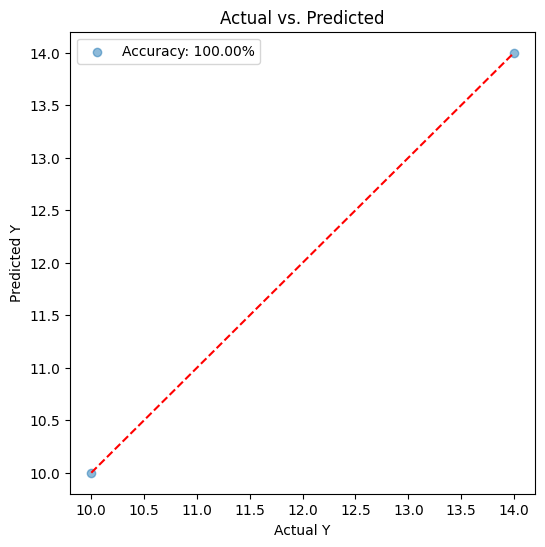

In [22]:
# Actual vs. Predicted Plot
plt.figure(figsize=(6, 6))
plt.scatter(Y, output.detach().numpy(), alpha=0.5)
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Actual vs. Predicted")
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')

# Compute accuracy
y_true = Y_tensor.squeeze().numpy()
y_pred = np.round(output.detach().numpy().squeeze())
accuracy = np.mean(y_true == y_pred)

plt.legend([f'Accuracy: {accuracy*100:.2f}%'])



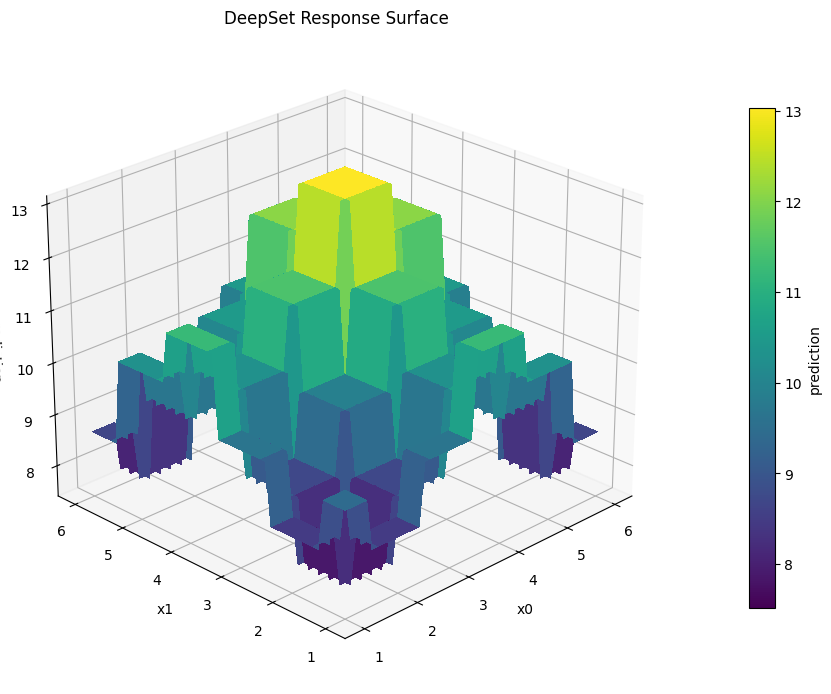

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------------
# Build mesh grid over the first two inputs
# ------------------------------------------------------------------

grid_step = 0.1

x0_values = np.arange(1, 6.01, grid_step)
x1_values = np.arange(1, 6.01, grid_step)

x0_grid, x1_grid = np.meshgrid(x0_values, x1_values)

# ------------------------------------------------------------------
# Build DeepSet inputs: [x0, x1, 1, 1, 1]
# ------------------------------------------------------------------

grid_points_int = np.column_stack([
    np.rint(x0_grid.ravel()),
    np.rint(x1_grid.ravel()),
    np.ones(x0_grid.size),
    np.ones(x0_grid.size),
    np.ones(x0_grid.size),
]).astype(int)

grid_points_int = np.clip(grid_points_int, 1, 6)

grid_points_onehot = np.eye(6)[grid_points_int - 1]

grid_points_tensor = torch.tensor(
    grid_points_onehot,
    dtype=torch.float32
)

# ------------------------------------------------------------------
# Evaluate model
# ------------------------------------------------------------------

model.eval()

with torch.no_grad():
    prediction_grid = model(grid_points_tensor).numpy().reshape(x0_grid.shape)

# ------------------------------------------------------------------
# Plot 3D response surface
# ------------------------------------------------------------------

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    x0_grid,
    x1_grid,
    prediction_grid,
    cmap="viridis",
    linewidth=0,
    antialiased=False,
    shade=True,
)

ax.set_title("DeepSet Response Surface")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_zlabel("prediction")

ax.view_init(elev=25, azim=-135)
ax.set_box_aspect((1, 1, 0.8))

fig.colorbar(
    surf,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label="prediction",
)

plt.tight_layout()
plt.show()